# CS436 Computer Vision Project - Week 1 Deliverable


**Student:** Muhammad Zain Naseer , Kousar Pervaiz



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from itertools import product
from PIL import Image
from PIL.ExifTags import TAGS
import open3d as o3d

from scipy.optimize import least_squares
from collections import defaultdict
import pickle
import os
from scipy.optimize import least_squares

import random
plt.rcParams['figure.figsize'] = (12, 10)

random.seed(42)
np.random.seed(42)



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Load Image Dataset



In [2]:

IMAGE_DIR = r"images"  


image_paths = sorted(glob.glob(f"{IMAGE_DIR}/*.jpg"))

print(f"{len(image_paths)} images")

26 images


In [3]:

images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  
    else:
        print(f"Warning: Could not load {path}")

print(f"Loaded {len(images)} images successfully")
if len(images) > 0:
    print(f"Image shape: {images[0].shape}")

Loaded 26 images successfully
Image shape: (8160, 6120, 3)


## 2. Display Image Grid (10 Images)

Displaying a grid of 10 images from the dataset to show the variety of viewpoints.

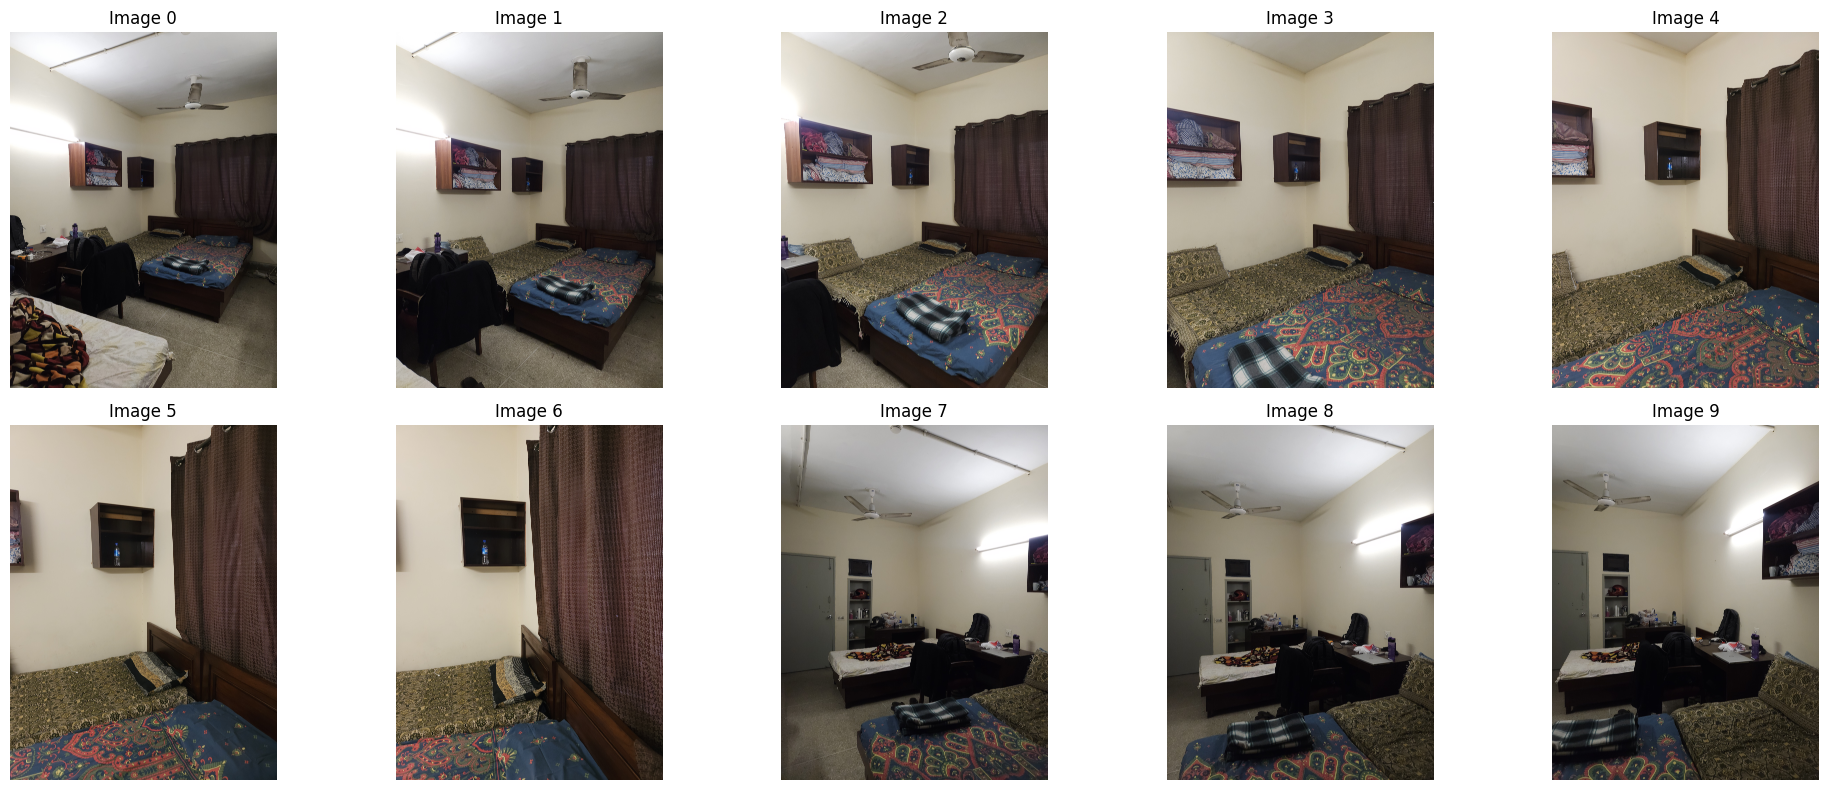

In [4]:
def display_image_grid(images, n_images, cols):

    n_images = min(n_images, len(images))
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for i in range(n_images):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Image {i}', fontsize=12)
        axes[i].axis('off')
    

    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

display_image_grid(images, n_images=10, cols=5)

## 3. Image Preprocessing



In [5]:
def preprocess_image(img, target_width=1920, convert_to_gray=True):

    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    

    h, w = img_bgr.shape[:2]
    if w > target_width:
        scale = target_width / w
        new_w = int(w * scale)
        new_h = int(h * scale)
        img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    

    

    if convert_to_gray:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
     
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


if len(images) > 0:
    sample_img = images[0]
    print(f"Original image shape: {sample_img.shape}")
    

    preprocessed_images = []
    for img in images:
        preprocessed = preprocess_image(img, convert_to_gray=True)
        preprocessed_images.append(preprocessed)
    
    print(f"Preprocessed {len(preprocessed_images)} images")
    print(f"Preprocessed image shape: {preprocessed_images[0].shape}")
    print(f"Image is now grayscale: {len(preprocessed_images[0].shape) == 2}")
else:
    preprocessed_images = images
    print("No preprocessing applied (using original images)")

Original image shape: (8160, 6120, 3)
Preprocessed 26 images
Preprocessed image shape: (2560, 1920)
Image is now grayscale: True


## 4. Feature Detection and Matching

Using SIFT (Scale-Invariant Feature Transform) to detect and match features between consecutive images.

### 4.1 Feature Detection Setup

In [6]:

sift = cv2.SIFT_create(nfeatures=10000)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

print("Feature detector and matcher initialized")

Feature detector and matcher initialized


### 4.2 Detect Features in All Images

In [7]:

keypoints_list = []
descriptors_list = []
images_color = []  

for i, img in enumerate(preprocessed_images):
    kp, desc = sift.detectAndCompute(img, None)
    keypoints_list.append(kp)
    descriptors_list.append(desc)
    
    
    img_color = preprocess_image(images[i], convert_to_gray=False)
    images_color.append(img_color)

print(f"\nTotal images processed: {len(keypoints_list)}")
print(f"Color images stored: {len(images_color)}")


Total images processed: 26
Color images stored: 26


### 4.3 Visualize Keypoints on Sample Image

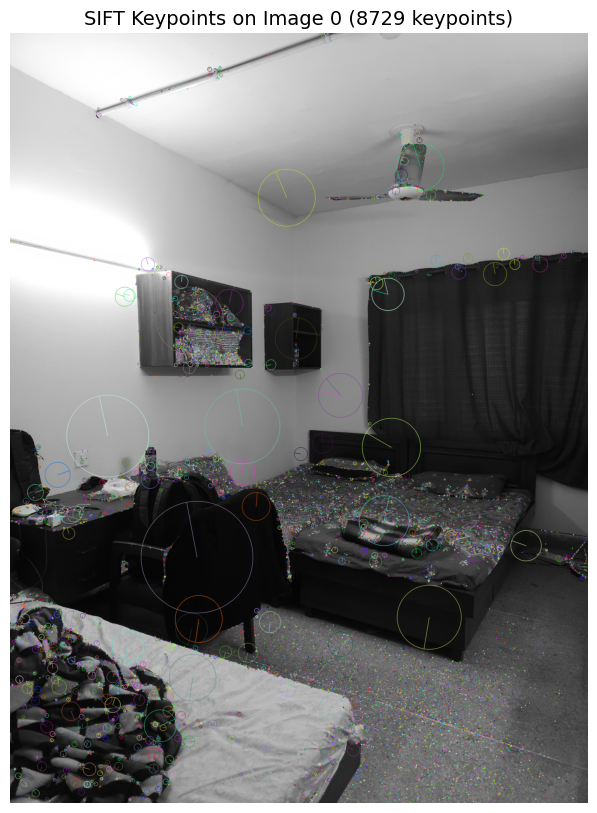

In [8]:

img_with_kp = cv2.drawKeypoints(
    cv2.cvtColor(preprocessed_images[0], cv2.COLOR_RGB2BGR),
    keypoints_list[0],
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints on Image 0 ({len(keypoints_list[0])} keypoints)', fontsize=14)
plt.axis('off')
plt.show()

## 5. Feature Matching Between Consecutive Images

Matching features between 4-5 consecutive image pairs using Lowe's ratio test.

In [9]:
def match_features(desc1, desc2, ratio_thresh=0.7):

    matches = flann.knnMatch(desc1, desc2, k=2)
    
    
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    
    return good_matches

def visualize_matches(img1, kp1, img2, kp2, matches, title=""):
    
    
    img1_bgr = cv2.cvtColor(img1, cv2.COLOR_RGB2BGR)
    img2_bgr = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
    
    
    img_matches = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=14)
    plt.axis('off')
    return img_matches

### 5.1 Match Features Between 4-5 Consecutive Image Pairs

Matching features between 5 consecutive image pairs


--- Matching Image 0 and Image 1 ---
Found 1185 good matches


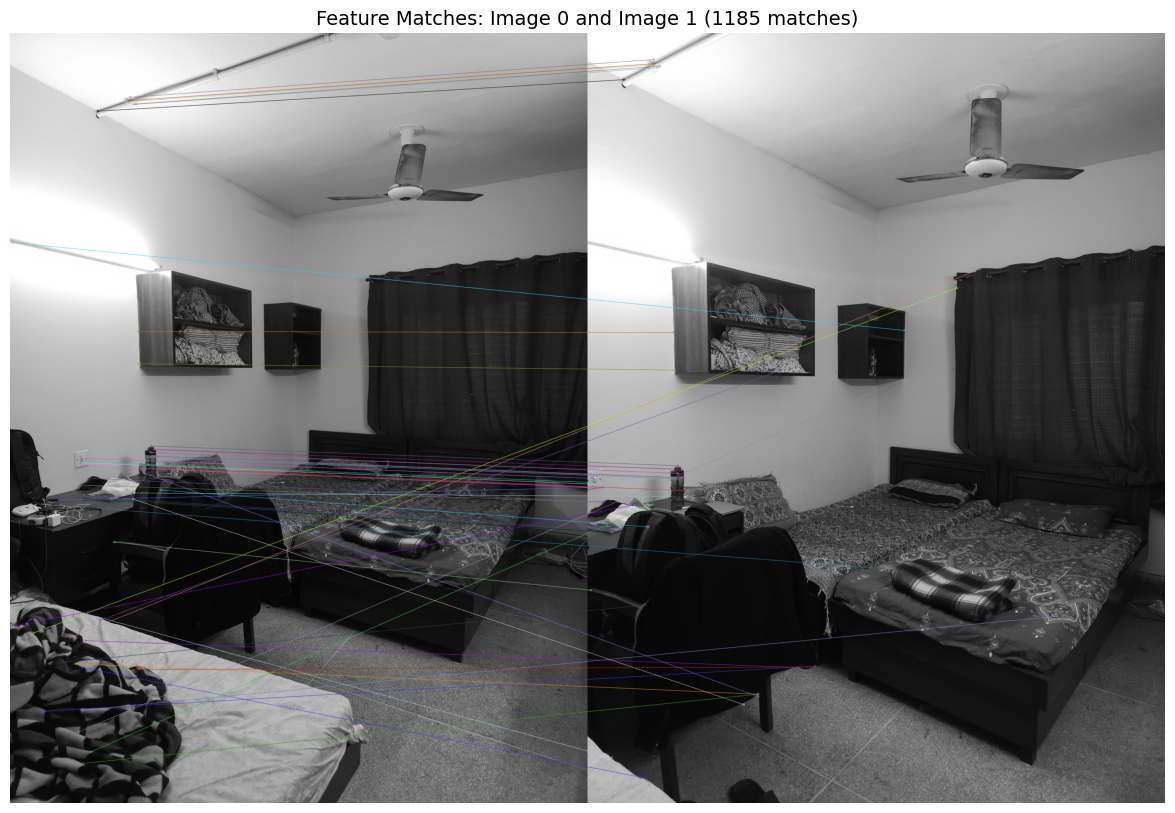


--- Matching Image 1 and Image 2 ---
Found 1087 good matches


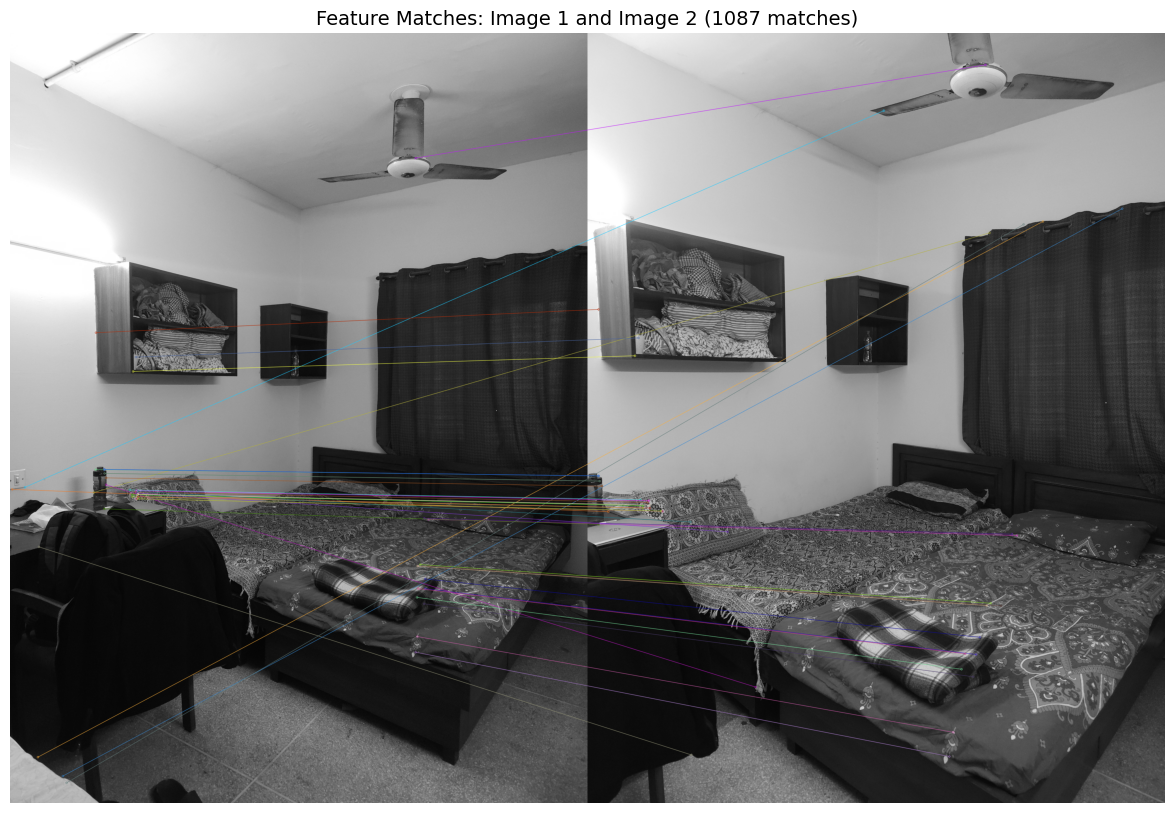


--- Matching Image 2 and Image 3 ---
Found 825 good matches


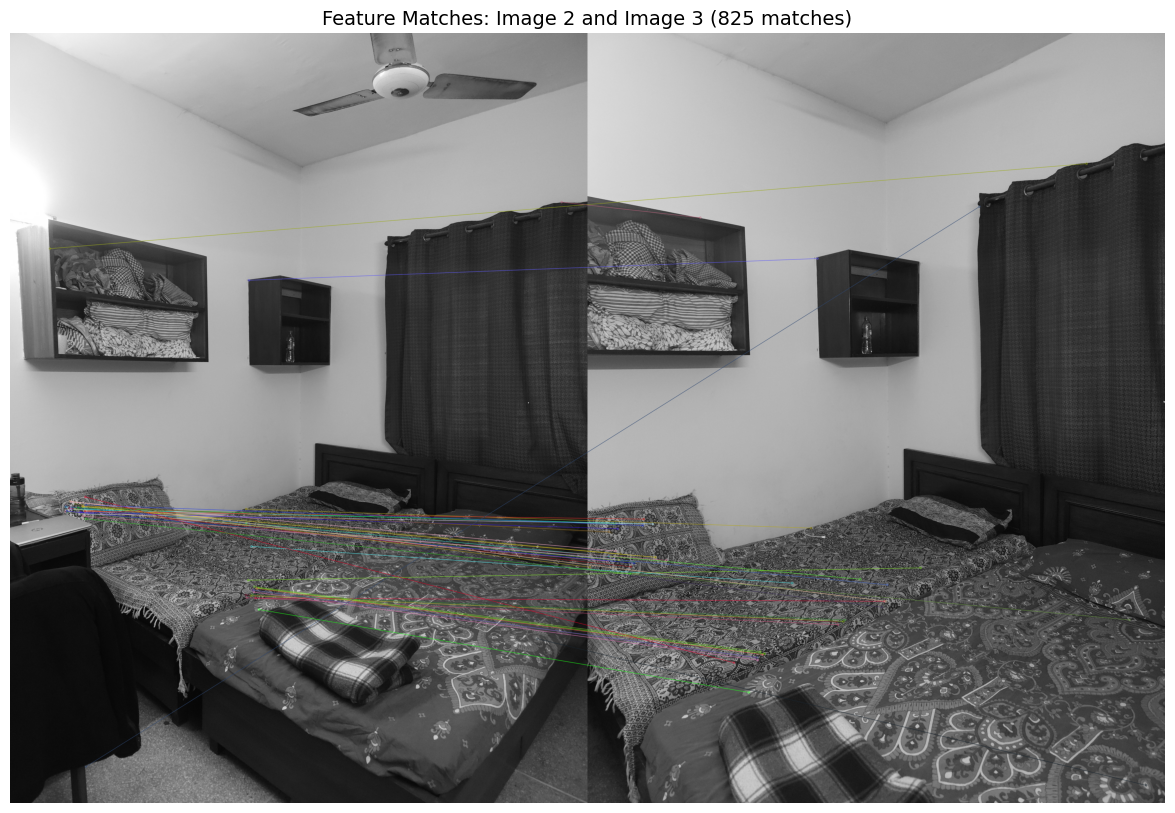


--- Matching Image 3 and Image 4 ---
Found 946 good matches


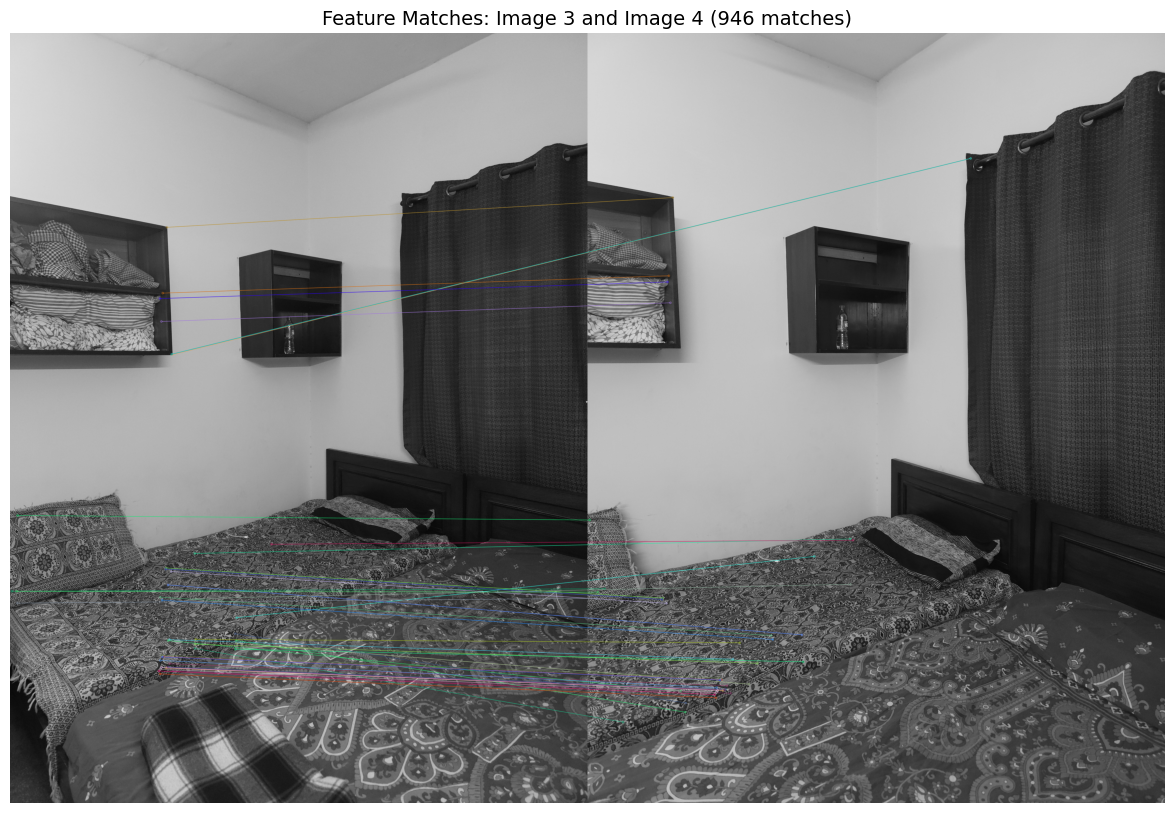


--- Matching Image 4 and Image 5 ---
Found 1065 good matches


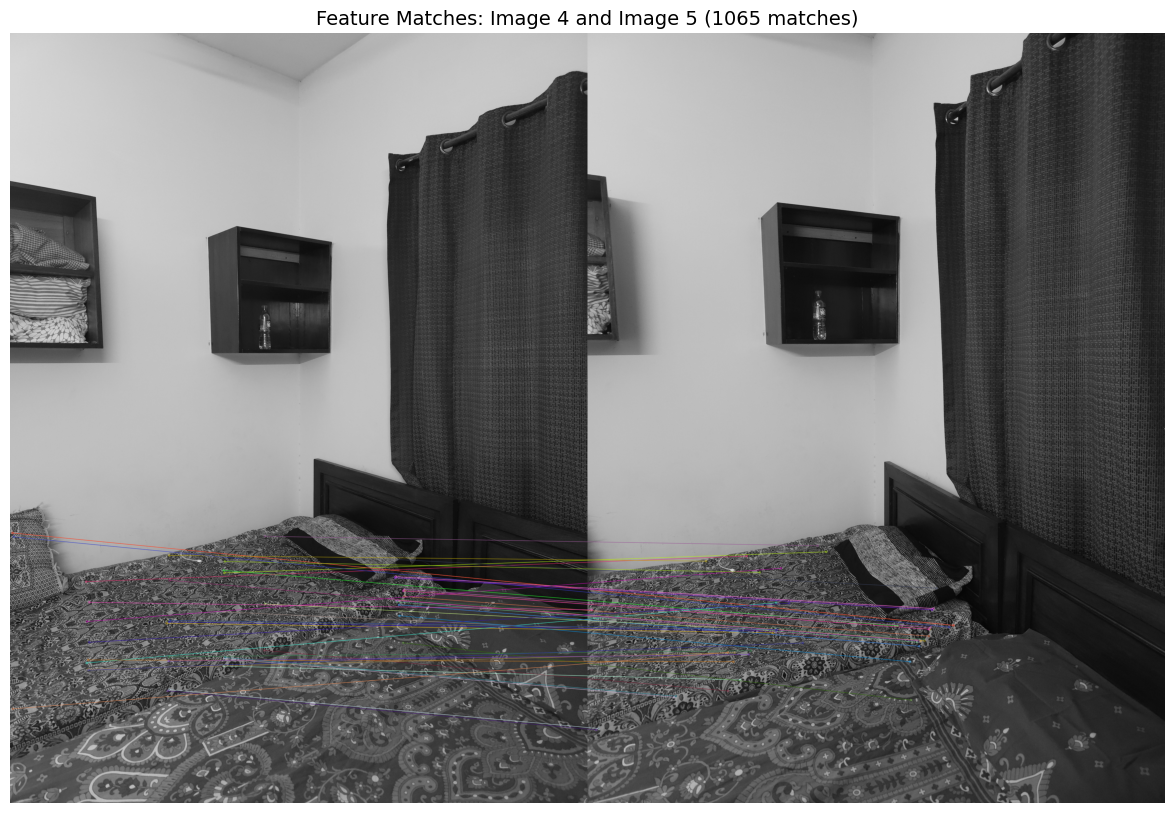

In [10]:

n_pairs = min(5, len(preprocessed_images) - 1)

print(f"Matching features between {n_pairs} consecutive image pairs\n")

for i in range(n_pairs):
    print(f"\n--- Matching Image {i} and Image {i+1} ---")
    
    
    matches = match_features(descriptors_list[i], descriptors_list[i+1])
    
    print(f"Found {len(matches)} good matches")
    
    
    title = f'Feature Matches: Image {i} and Image {i+1} ({len(matches)} matches)'
    visualize_matches(
        preprocessed_images[i], keypoints_list[i],
        preprocessed_images[i+1], keypoints_list[i+1],
        matches, title
    )
    
    

    plt.show()

---

# Week 2: Two-View Reconstruction



In [11]:


img1_gray = preprocessed_images[0]
img2_gray = preprocessed_images[1]
img1_color = images_color[0]
img2_color = images_color[1]

kp1 = keypoints_list[0]
kp2 = keypoints_list[1]
desc1 = descriptors_list[0]
desc2 = descriptors_list[1]

print(f"\nUsing Image 0 and Image 1 for reconstruction")
print(f"Image 1: {len(kp1)} keypoints")
print(f"Image 2: {len(kp2)} keypoints")


matches = match_features(desc1, desc2, ratio_thresh=0.75)
print(f"Found {len(matches)} matches")


Using Image 0 and Image 1 for reconstruction
Image 1: 8729 keypoints
Image 2: 10000 keypoints
Found 1371 matches


In [12]:

def get_camera_intrinsics_from_exif(image_path, img_shape):

    img = Image.open(image_path)
    exif = img._getexif()
    
    if exif is None:
        print("No EXIF data found, using estimation")
        return estimate_camera_intrinsics(img_shape)
    
    
    exif_data = {}
    for tag_id, value in exif.items():
        tag = TAGS.get(tag_id, tag_id)
        exif_data[tag] = value
    
    
    focal_length_mm = float(exif_data.get('FocalLength', 0))
    focal_length_35mm = exif_data.get('FocalLengthIn35mmFilm', 0)
    
    
    orig_width = exif_data.get('ExifImageWidth', img_shape[1])
    orig_height = exif_data.get('ExifImageHeight', img_shape[0])
    
    print(f"Camera: {exif_data.get('Make', 'Unknown')} {exif_data.get('Model', 'Unknown')}")
    print(f"Focal length: {focal_length_mm}mm (35mm equivalent: {focal_length_35mm}mm)")
    print(f"Original image size: {orig_width}x{orig_height}")
    
    
    
    
    if focal_length_35mm > 0:
        
        focal_pixels = (focal_length_35mm / 36.0) * orig_width
    else:
        
        sensor_width_mm = 6.17  
        focal_pixels = (focal_length_mm / sensor_width_mm) * orig_width
    
    
    scale = img_shape[1] / orig_width
    focal_scaled = focal_pixels * scale
    
    
    cx = img_shape[1] / 2.0
    cy = img_shape[0] / 2.0
    
    
    K = np.array([
        [focal_scaled, 0, cx],
        [0, focal_scaled, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def estimate_camera_intrinsics(img_shape):
 
    h, w = img_shape[:2]
    focal_length = max(w, h) * 1.2
    cx = w / 2.0
    cy = h / 2.0
    
    K = np.array([
        [focal_length, 0, cx],
        [0, focal_length, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def filter_points(points_3d, pts1, pts2, R, t, K, max_reproj_error=5.0, max_depth=100.0):
    """Filter 3D points based on validity checks - RELAXED VERSION"""
    valid_mask = np.ones(len(points_3d), dtype=bool)
    
    
    depths1 = points_3d[:, 2]   
    valid_mask &= depths1 > 0
    
    
    points_cam2 = (R @ points_3d.T + t).T
    depths2 = points_cam2[:, 2]
    valid_mask &= depths2 > 0
    
    
    valid_mask &= depths1 < max_depth * 2  
    valid_mask &= depths2 < max_depth * 2
    
    
    points_2d_proj = (K @ points_3d.T).T
    points_2d_proj = points_2d_proj[:, :2] / points_2d_proj[:, 2:3]
    reproj_error1 = np.linalg.norm(points_2d_proj - pts1, axis=1)
    valid_mask &= reproj_error1 < max_reproj_error
    
    
    points_2d_proj2 = (K @ points_cam2.T).T
    points_2d_proj2 = points_2d_proj2[:, :2] / points_2d_proj2[:, 2:3]
    reproj_error2 = np.linalg.norm(points_2d_proj2 - pts2, axis=1)
    valid_mask &= reproj_error2 < max_reproj_error
    
    return valid_mask

In [13]:
print("Camera Intrinsic Matrix K (from EXIF)")
K = get_camera_intrinsics_from_exif(image_paths[0], img1_gray.shape)
print(f"Camera Intrinsic Matrix K:")
print(K)
print(f"Focal length: {K[0,0]:.2f} pixels")
print(f"Principal point: ({K[0,2]:.2f}, {K[1,2]:.2f})")

Camera Intrinsic Matrix K (from EXIF)
Camera: samsung Galaxy S23
Focal length: 5.4mm (35mm equivalent: 23mm)
Original image size: 8160x6120
Camera Intrinsic Matrix K:
[[1.22666667e+03 0.00000000e+00 9.60000000e+02]
 [0.00000000e+00 1.22666667e+03 1.28000000e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Focal length: 1226.67 pixels
Principal point: (960.00, 1280.00)


In [14]:


ratio_thresholds = [0.75, 0.8, 0.85, 0.9]  
ransac_thresholds = [1.0, 1.5, 2.0, 3.0]  
reproj_errors = [10.0, 15.0, 20.0]  

best_params = None
best_points = 0

print("Testing parameter combinations...\n")

for ratio, ransac_th, reproj_err in product(ratio_thresholds, ransac_thresholds, reproj_errors):
    
    test_matches = match_features(descriptors_list[0], descriptors_list[1], ratio_thresh=ratio)
    if len(test_matches) < 8:
        continue
    
    pts1_test = np.float32([keypoints_list[0][m.queryIdx].pt for m in test_matches])
    pts2_test = np.float32([keypoints_list[1][m.trainIdx].pt for m in test_matches])
    K_test = estimate_camera_intrinsics(preprocessed_images[0].shape)
    
    E_test, mask_test = cv2.findEssentialMat(pts1_test, pts2_test, K_test, 
                                              method=cv2.RANSAC, prob=0.999, threshold=ransac_th)
    if E_test is None:
        continue
    
    inliers_test = mask_test.ravel() == 1
    pts1_in = pts1_test[inliers_test]
    pts2_in = pts2_test[inliers_test]
    
    if len(pts1_in) < 8:
        continue
    
    _, R_test, t_test, _ = cv2.recoverPose(E_test, pts1_in, pts2_in, K_test)
    
    P1_test = K_test @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2_test = K_test @ np.hstack([R_test, t_test])
    pts_4d = cv2.triangulatePoints(P1_test, P2_test, pts1_in.T, pts2_in.T)
    pts_3d = (pts_4d[:3] / pts_4d[3]).T
    
    valid = filter_points(pts_3d, pts1_in, pts2_in, R_test, t_test, K_test, max_reproj_error=reproj_err)
    num_valid = np.sum(valid)
    
    if num_valid > best_points:
        best_points = num_valid
        best_params = {'ratio': ratio, 'ransac': ransac_th, 'reproj': reproj_err}
        print(f"New best: {num_valid} points | ratio={ratio}, ransac={ransac_th}, reproj={reproj_err}")

print(f"\n{'='*50}")
print(f"BEST PARAMETERS: {best_params}")
print(f"Expected points: {best_points}")
print(f"{'='*50}")

BEST_RATIO = best_params['ratio']
BEST_RANSAC = best_params['ransac']
BEST_REPROJ = best_params['reproj']

Testing parameter combinations...

New best: 574 points | ratio=0.75, ransac=1.0, reproj=10.0
New best: 591 points | ratio=0.75, ransac=1.0, reproj=15.0
New best: 599 points | ratio=0.75, ransac=1.0, reproj=20.0
New best: 654 points | ratio=0.75, ransac=1.5, reproj=10.0
New best: 716 points | ratio=0.75, ransac=2.0, reproj=10.0
New best: 721 points | ratio=0.75, ransac=2.0, reproj=15.0
New best: 730 points | ratio=0.75, ransac=2.0, reproj=20.0
New best: 806 points | ratio=0.75, ransac=3.0, reproj=10.0
New best: 829 points | ratio=0.75, ransac=3.0, reproj=20.0
New best: 889 points | ratio=0.8, ransac=3.0, reproj=10.0
New best: 922 points | ratio=0.8, ransac=3.0, reproj=15.0
New best: 965 points | ratio=0.85, ransac=3.0, reproj=10.0
New best: 975 points | ratio=0.85, ransac=3.0, reproj=15.0
New best: 1028 points | ratio=0.85, ransac=3.0, reproj=20.0
New best: 1118 points | ratio=0.9, ransac=3.0, reproj=10.0

BEST PARAMETERS: {'ratio': 0.9, 'ransac': 3.0, 'reproj': 10.0}
Expected points: 

## 2. Essential Matrix Estimation

Compute Essential matrix using RANSAC to filter outliers.


Essential Matrix Estimation
Using 1371 matched points
[[-0.0057465  -0.51932131 -0.13975364]
 [ 0.55272455 -0.0145727  -0.41891262]
 [ 0.15077959  0.45457124  0.01293057]]

Inliers after RANSAC: 775 / 1371
Inlier ratio: 56.53%


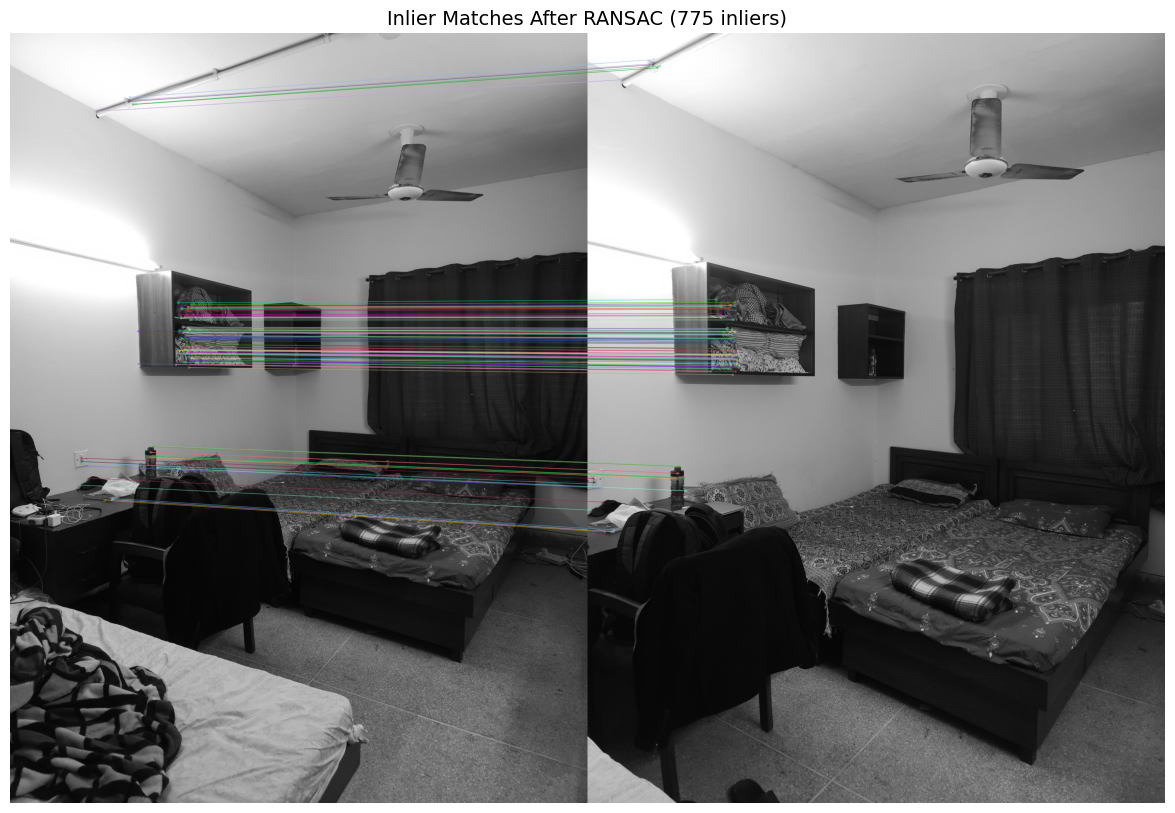

In [15]:

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

print("\nEssential Matrix Estimation")
print(f"Using {len(pts1)} matched points")



E, mask_e = cv2.findEssentialMat(
    pts1, pts2, K, 
    method=cv2.RANSAC, 
    prob=0.999, 
    threshold=BEST_RANSAC  
)


inliers = mask_e.ravel() == 1
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]
matches_inliers = [matches[i] for i in range(len(matches)) if inliers[i]]

print(E)
print(f"\nInliers after RANSAC: {np.sum(inliers)} / {len(pts1)}")
print(f"Inlier ratio: {np.sum(inliers)/len(pts1)*100:.2f}%")


img_inliers = cv2.drawMatches(
    img1_gray, kp1, img2_gray, kp2, matches_inliers[:100], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(img_inliers, cmap='gray')
plt.title(f'Inlier Matches After RANSAC ({len(matches_inliers)} inliers)', fontsize=14)
plt.axis('off')
plt.show()

## 3. Camera Pose Recovery



In [16]:



num_inliers, R, t, mask_pose = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)

print(f"\nRotation Matrix R:")
print(R)
print(f"\nTranslation Vector t:")
print(t.ravel())
print(f"\nNumber of points in front of both cameras: {num_inliers}")


det_R = np.linalg.det(R)
print(f"\nDeterminant of R (should be ~1): {det_R:.6f}")
print(f"R is orthogonal: {np.allclose(R @ R.T, np.eye(3))}")


Rotation Matrix R:
[[ 0.99671789 -0.03113826  0.07472525]
 [ 0.03078679  0.99950885  0.00585104]
 [-0.07487074 -0.00353128  0.99718699]]

Translation Vector t:
[-0.64921688  0.19388358 -0.73547713]

Number of points in front of both cameras: 775

Determinant of R (should be ~1): 1.000000
R is orthogonal: True


## 4. 3D Point Triangulation

Triangulate 3D points from two camera views.

In [17]:




P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])


P2 = K @ np.hstack([R, t])

print("Projection Matrix P1 (Camera 1):")
print(P1)
print("\nProjection Matrix P2 (Camera 2):")
print(P2)


print(f"\nTriangulating {len(pts1_inliers)} points...")
points_4d_hom = cv2.triangulatePoints(P1, P2, pts1_inliers.T, pts2_inliers.T)


points_3d = points_4d_hom[:3] / points_4d_hom[3]
points_3d = points_3d.T  

print(f"Generated {len(points_3d)} 3D points")
print(f"\n3D points statistics:")
print(f"X range: [{points_3d[:, 0].min():.2f}, {points_3d[:, 0].max():.2f}]")
print(f"Y range: [{points_3d[:, 1].min():.2f}, {points_3d[:, 1].max():.2f}]")
print(f"Z range: [{points_3d[:, 2].min():.2f}, {points_3d[:, 2].max():.2f}]")

Projection Matrix P1 (Camera 1):
[[1.22666667e+03 0.00000000e+00 9.60000000e+02 0.00000000e+00]
 [0.00000000e+00 1.22666667e+03 1.28000000e+03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Projection Matrix P2 (Camera 2):
[[ 1.15076470e+03 -4.15863003e+01  1.04896249e+03 -1.50243074e+03]
 [-5.80694142e+01  1.22154414e+03  1.28357663e+03 -7.03580191e+02]
 [-7.48707404e-02 -3.53128386e-03  9.97186995e-01 -7.35477125e-01]]

Triangulating 775 points...
Generated 775 3D points

3D points statistics:
X range: [-2.54, 3.56]
Y range: [-3.55, 2.73]
Z range: [3.48, 8.08]


In [18]:
# Filter 3D points and keep consistent indices
valid_mask = filter_points(
    points_3d,
    pts1_inliers,
    pts2_inliers,
    R,
    t,
    K,
    max_reproj_error=BEST_REPROJ
)

# Indices of points that passed the validity checks
valid_indices = np.where(valid_mask)[0]

# Keep only the valid 3D points
points_3d_filtered = points_3d[valid_indices]

print(f"Valid points after filtering: {len(points_3d_filtered)} / {len(points_3d)}")
print(f"Filtered ratio: {len(points_3d_filtered)/len(points_3d)*100:.2f}%")

print(f"Filtered 3D points statistics:")
print(f"X range: [{points_3d_filtered[:, 0].min():.2f}, {points_3d_filtered[:, 0].max():.2f}]")
print(f"Y range: [{points_3d_filtered[:, 1].min():.2f}, {points_3d_filtered[:, 1].max():.2f}]")
print(f"Z range: [{points_3d_filtered[:, 2].min():.2f}, {points_3d_filtered[:, 2].max():.2f}]")

# Extract colors for the valid points from image 1


Valid points after filtering: 775 / 775
Filtered ratio: 100.00%
Filtered 3D points statistics:
X range: [-2.54, 3.56]
Y range: [-3.55, 2.73]
Z range: [3.48, 8.08]


## 5. Extract Point Colors

Get RGB colors for each 3D point from the original image.

In [19]:
colors = []
for idx in valid_indices:
    x, y = pts1_inliers[idx].astype(int)

    # Safety clamp
    y = np.clip(y, 0, img1_color.shape[0] - 1)
    x = np.clip(x, 0, img1_color.shape[1] - 1)

    color = img1_color[y, x]
    colors.append(color)

colors = np.array(colors)
print(f"\nExtracted colors for {len(colors)} points (matching filtered 3D points)")



Extracted colors for 775 points (matching filtered 3D points)


## 6. 2D Scatter Plots of 3D Point Cloud

Display 2D projections (XY, XZ, YZ) of the reconstructed point cloud.

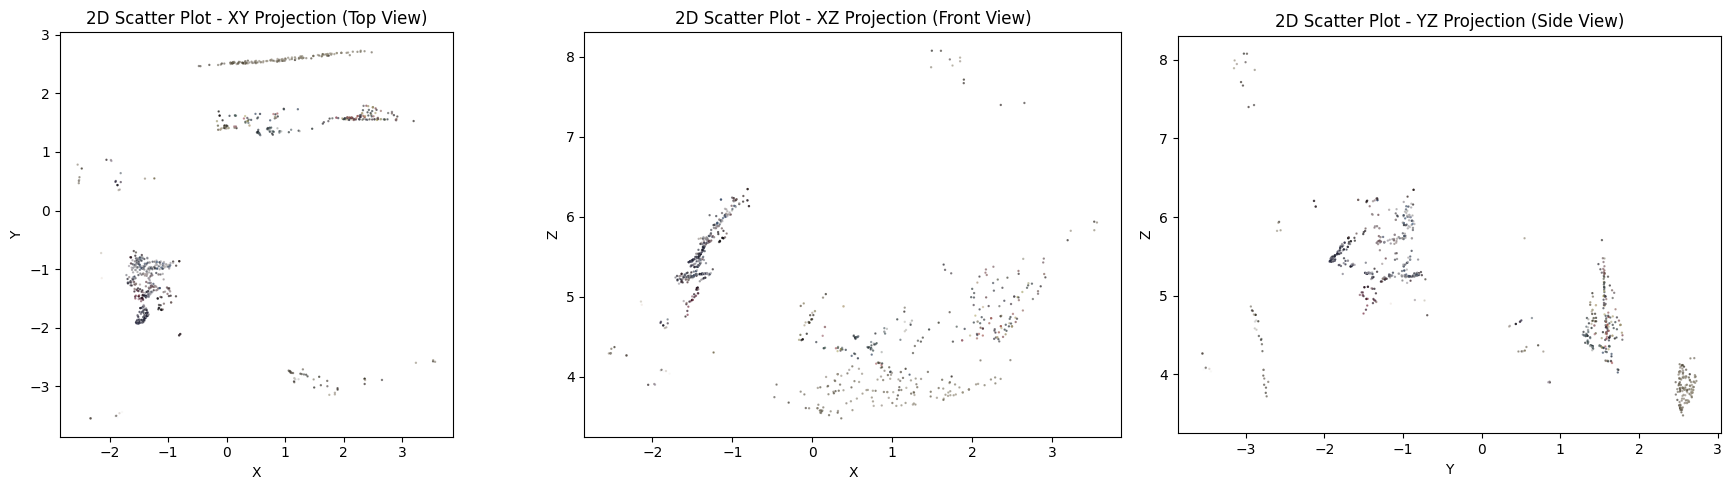

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 1], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('2D Scatter Plot - XY Projection (Top View)')
axes[0].set_aspect('equal')


axes[1].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].set_title('2D Scatter Plot - XZ Projection (Front View)')
axes[1].set_aspect('equal')


axes[2].scatter(points_3d_filtered[:, 1], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].set_title('2D Scatter Plot - YZ Projection (Side View)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## 7. 3D Point Cloud Visualization

Display the reconstructed point cloud with camera positions.

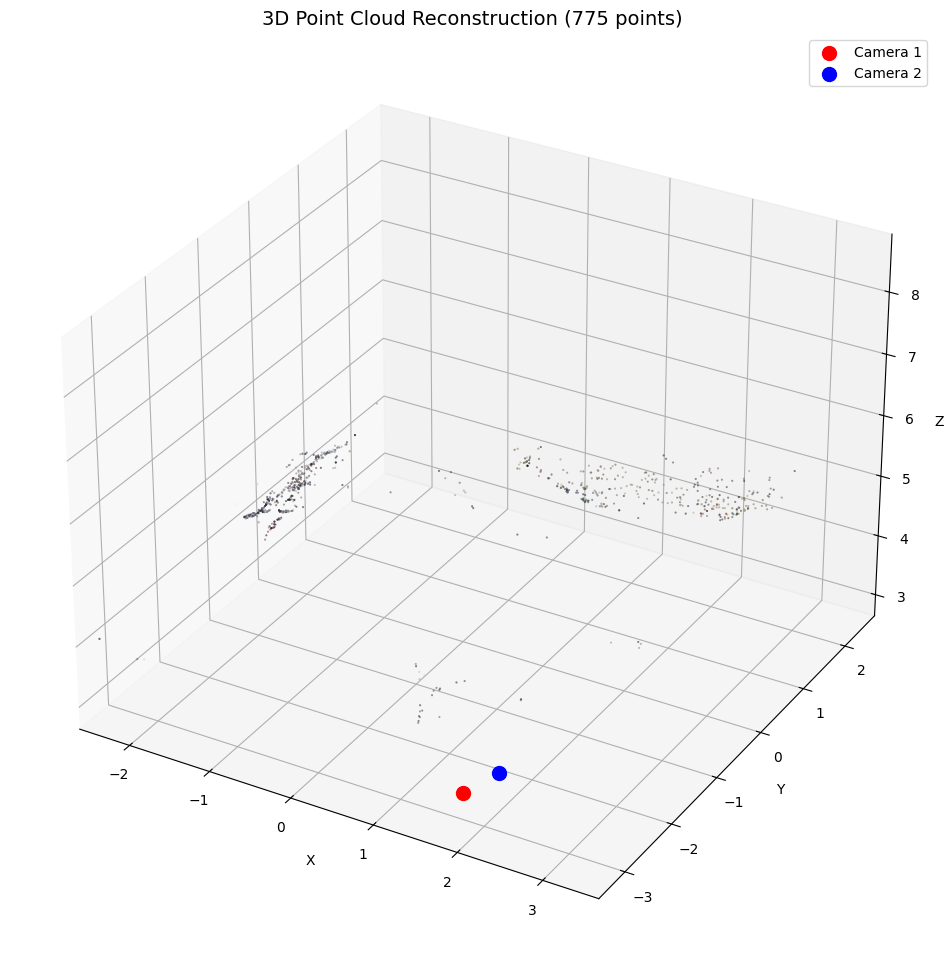

In [21]:

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(
    points_3d_filtered[:, 0], 
    points_3d_filtered[:, 1], 
    points_3d_filtered[:, 2],
    c=colors/255.0,  
    marker='.',
    s=1,
    alpha=0.6
)


ax.scatter([0], [0], [0], c='red', marker='o', s=100, label='Camera 1')
cam2_pos = -R.T @ t
ax.scatter([cam2_pos[0]], [cam2_pos[1]], [cam2_pos[2]], 
           c='blue', marker='o', s=100, label='Camera 2')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D Point Cloud Reconstruction ({len(points_3d_filtered)} points)', fontsize=14)
ax.legend()


max_range = np.array([
    points_3d_filtered[:, 0].max() - points_3d_filtered[:, 0].min(),
    points_3d_filtered[:, 1].max() - points_3d_filtered[:, 1].min(),
    points_3d_filtered[:, 2].max() - points_3d_filtered[:, 2].min()
]).max() / 2.0

mid_x = (points_3d_filtered[:, 0].max() + points_3d_filtered[:, 0].min()) * 0.5
mid_y = (points_3d_filtered[:, 1].max() + points_3d_filtered[:, 1].min()) * 0.5
mid_z = (points_3d_filtered[:, 2].max() + points_3d_filtered[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()

## 8. Save Point Cloud as PLY File

Export the final 3D point cloud to PLY format.

In [22]:
def save_ply(filename, points, colors):
  
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        
        for i in range(len(points)):
            f.write(f"{points[i, 0]:.6f} {points[i, 1]:.6f} {points[i, 2]:.6f} ")
            f.write(f"{int(colors[i, 0])} {int(colors[i, 1])} {int(colors[i, 2])}\n")
    
    print(f"Saved {len(points)} points to {filename}")


save_ply('reconstruction.ply', points_3d_filtered, colors)
print(f"\nPoint cloud saved successfully!")

Saved 775 points to reconstruction.ply

Point cloud saved successfully!


## 9. Inline Point Cloud Visualization

Display the reconstructed point cloud from multiple angles directly in the notebook.

Loaded 775 points from reconstruction.ply


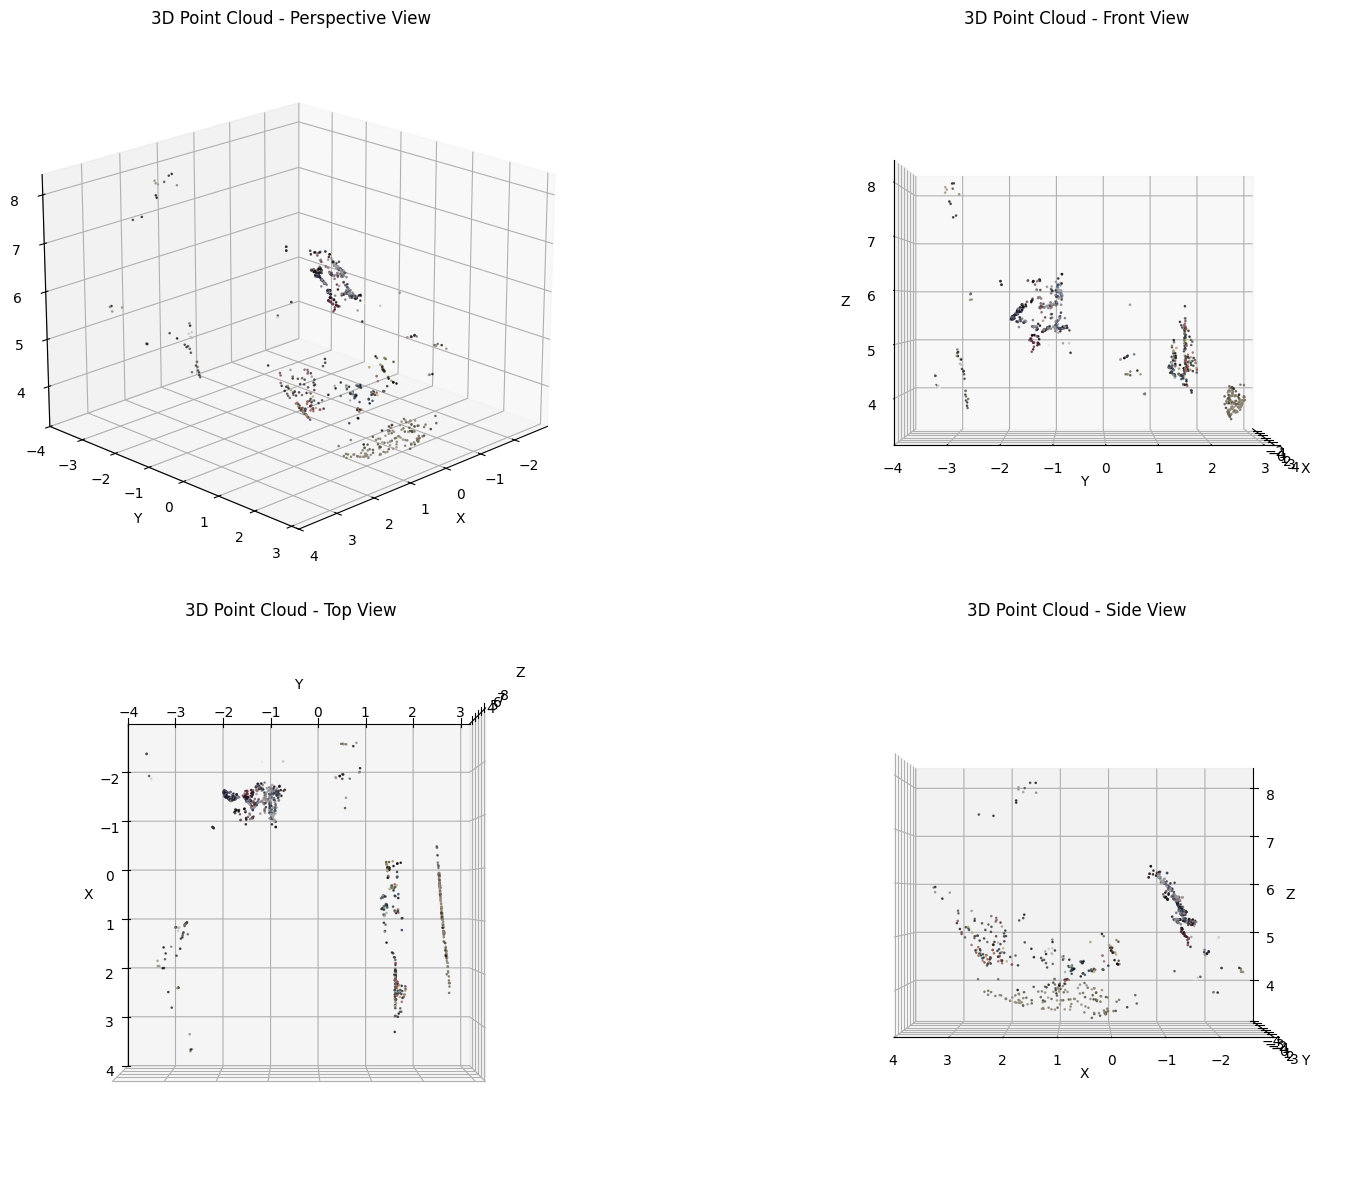


Point cloud visualization complete!
  Total points: 775
  X range: [-2.54, 3.56]
  Y range: [-3.55, 2.73]
  Z range: [3.48, 8.08]


In [23]:



def read_ply(filename):
   
    points = []
    colors = []
    
    with open(filename, 'r') as f:
        
        line = f.readline()
        while 'end_header' not in line:
            line = f.readline()
        
        
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                points.append([float(parts[0]), float(parts[1]), float(parts[2])])
                colors.append([int(parts[3]), int(parts[4]), int(parts[5])])
    
    return np.array(points), np.array(colors)


ply_points, ply_colors = read_ply('reconstruction.ply')
print(f"Loaded {len(ply_points)} points from reconstruction.ply")


fig = plt.figure(figsize=(18, 12))


ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Point Cloud - Perspective View')
ax1.view_init(elev=20, azim=45)


ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Point Cloud - Front View')
ax2.view_init(elev=0, azim=0)


ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('3D Point Cloud - Top View')
ax3.view_init(elev=90, azim=0)


ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('3D Point Cloud - Side View')
ax4.view_init(elev=0, azim=90)

plt.tight_layout()
plt.show()

print(f"\nPoint cloud visualization complete!")
print(f"  Total points: {len(ply_points)}")
print(f"  X range: [{ply_points[:, 0].min():.2f}, {ply_points[:, 0].max():.2f}]")
print(f"  Y range: [{ply_points[:, 1].min():.2f}, {ply_points[:, 1].max():.2f}]")
print(f"  Z range: [{ply_points[:, 2].min():.2f}, {ply_points[:, 2].max():.2f}]")

## 10. Interactive Open3D Visualization

Open the point cloud in an interactive 3D viewer window (requires running the cell).

In [24]:

print("Opening interactive 3D viewer...")
pcd = o3d.io.read_point_cloud("reconstruction.ply")
print(f"Points in reconstruction.ply: {len(pcd.points)}")
#o3d.visualization.draw_geometries([pcd], window_name="Two-View Reconstruction")

Opening interactive 3D viewer...
Points in reconstruction.ply: 775



# Week 3: Incremental SfM

## 1. Prepare Data Structures for Incremental SfM

In [25]:
# Initial registered images (first two views)
registered_images = {0, 1}

# Initial poses: camera 0 is reference, camera 1 from recoverPose()
pose1 = np.hstack([np.eye(3), np.zeros((3, 1))])
pose2 = np.hstack([R, t])
poses = {0: pose1, 1: pose2}

# Map from keypoints to 3D points for each image
point_cloud_indices = {}
point_cloud_indices[0] = np.full(len(keypoints_list[0]), -1, dtype=int)
point_cloud_indices[1] = np.full(len(keypoints_list[1]), -1, dtype=int)

# IMPORTANT:
# Only matches whose 3D points survived filtering (valid_indices) get 3D indices
# We assign new consecutive indices [0 .. len(points_3d_filtered)-1]
for new_idx, old_idx in enumerate(valid_indices):
    m = matches_inliers[old_idx]
    # m.queryIdx -> kp in image 0, m.trainIdx -> kp in image 1
    point_cloud_indices[0][m.queryIdx] = new_idx
    point_cloud_indices[1][m.trainIdx] = new_idx

# Global 3D map and colors used by incremental SfM
points_3d_map = points_3d_filtered.copy()
colors_map = colors.copy()

print(f"Initial reconstruction state:")
print(f"  Registered images: {registered_images}")
print(f"  Number of cameras: {len(poses)}")
print(f"  Number of 3D points: {len(points_3d_map)}")
print(f"  Image 0: {np.sum(point_cloud_indices[0] >= 0)} keypoints with 3D points")
print(f"  Image 1: {np.sum(point_cloud_indices[1] >= 0)} keypoints with 3D points")


Initial reconstruction state:
  Registered images: {0, 1}
  Number of cameras: 2
  Number of 3D points: 775
  Image 0: 775 keypoints with 3D points
  Image 1: 771 keypoints with 3D points


## 2. PnP Function - Add New View

This function localizes a new camera by finding 2D-3D correspondences with already registered images.

In [26]:
def add_view_with_pnp(new_img_idx, registered_images, keypoints_list, descriptors_list,
                      points_3d_map, point_cloud_indices, K, ratio_thresh=0.75, min_matches=15):

    print(f"Attempting to add Image {new_img_idx} using PnP")

    
    points_2d = []
    points_3d_corr = []
    
    for reg_img_idx in registered_images:
        matches = match_features(descriptors_list[new_img_idx], 
                               descriptors_list[reg_img_idx], 
                               ratio_thresh)
        
        for m in matches:
            kp_idx_new = m.queryIdx
            kp_idx_reg = m.trainIdx
            
            if reg_img_idx in point_cloud_indices:
                pt_3d_idx = point_cloud_indices[reg_img_idx][kp_idx_reg]
                
                if pt_3d_idx >= 0 and pt_3d_idx < len(points_3d_map):
                    pt_2d = keypoints_list[new_img_idx][kp_idx_new].pt
                    points_2d.append(pt_2d)
                    points_3d_corr.append(points_3d_map[pt_3d_idx])
    
    points_2d = np.array(points_2d, dtype=np.float32)
    points_3d_corr = np.array(points_3d_corr, dtype=np.float32)
    
    print(f"Found {len(points_2d)} 2D-3D correspondences")
    
    if len(points_2d) < min_matches:
        print(f"❌ Not enough correspondences (need {min_matches})")
        return None
    
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        points_3d_corr,
        points_2d,
        K,
        None,
        flags=cv2.SOLVEPNP_ITERATIVE,
        reprojectionError=10.0,
        confidence=0.99,
        iterationsCount=1000
    )
    
    if not success or inliers is None or len(inliers) < 10:
        print("❌ PnP failed")
        return None
    
    R_new, _ = cv2.Rodrigues(rvec)
    t_new = tvec
    pose_new = np.hstack([R_new, t_new])
    
    num_inliers = len(inliers)
    inlier_ratio = num_inliers / len(points_2d) * 100
    
    print(f"✅ PnP successful!")
    print(f"  Inliers: {num_inliers} / {len(points_2d)} ({inlier_ratio:.1f}%)")
    
    return pose_new

## 3. Triangulation Function - Add New Points

After adding a camera, triangulate new 3D points between the new view and existing views.

In [27]:
def triangulate_new_points_with_view(new_img_idx, registered_images, poses,
                                   keypoints_list, descriptors_list,
                                   points_3d_map, colors_map, point_cloud_indices,
                                   images_color, K, ratio_thresh=0.75):
    print(f"\nTriangulating new points with Image {new_img_idx}...")
    
    if new_img_idx not in poses:
        print(f"  Error: Image {new_img_idx} not in poses")
        return points_3d_map, colors_map, point_cloud_indices
    
    new_points = []
    new_colors = []
    new_correspondences = []
    
    P_new = K @ poses[new_img_idx]
    
    if new_img_idx not in point_cloud_indices:
        point_cloud_indices[new_img_idx] = np.full(len(keypoints_list[new_img_idx]), -1, dtype=int)
    
    for reg_img_idx in registered_images:
        if reg_img_idx == new_img_idx or reg_img_idx not in poses:
            continue
        
        matches = match_features(descriptors_list[new_img_idx],
                               descriptors_list[reg_img_idx],
                               ratio_thresh=0.85)
        
        if len(matches) < 8:
            continue
        
        P_reg = K @ poses[reg_img_idx]
        
        valid_matches = []
        for m in matches:
            kp_new = m.queryIdx
            if point_cloud_indices[new_img_idx][kp_new] < 0:
                valid_matches.append(m)
        
        if len(valid_matches) < 8:
            continue
        
        print(f"  Trying {len(valid_matches)} points with image {reg_img_idx}...")
        
        pts_new = np.float32([keypoints_list[new_img_idx][m.queryIdx].pt for m in valid_matches])
        pts_reg = np.float32([keypoints_list[reg_img_idx][m.trainIdx].pt for m in valid_matches])
        
        points_4d = cv2.triangulatePoints(P_reg, P_new, pts_reg.T, pts_new.T)
        points_3d_new = (points_4d[:3] / points_4d[3]).T
        
        R_new = poses[new_img_idx][:, :3]
        t_new = poses[new_img_idx][:, 3:]
        R_reg = poses[reg_img_idx][:, :3]
        t_reg = poses[reg_img_idx][:, 3:]
        
        points_cam_new = (R_new @ points_3d_new.T + t_new).T
        points_cam_reg = (R_reg @ points_3d_new.T + t_reg).T
        
        depths_new = points_cam_new[:, 2]
        depths_reg = points_cam_reg[:, 2]
        valid_mask = (depths_new > 0.1) & (depths_new < 200.0)
        valid_mask &= (depths_reg > 0.1) & (depths_reg < 200.0)
        
        points_2d_proj_new = (K @ points_cam_new.T).T
        points_2d_proj_new = points_2d_proj_new[:, :2] / points_2d_proj_new[:, 2:3]
        reproj_error_new = np.linalg.norm(points_2d_proj_new - pts_new, axis=1)
        valid_mask &= reproj_error_new < 15.0
        
        points_2d_proj_reg = (K @ points_cam_reg.T).T
        points_2d_proj_reg = points_2d_proj_reg[:, :2] / points_2d_proj_reg[:, 2:3]
        reproj_error_reg = np.linalg.norm(points_2d_proj_reg - pts_reg, axis=1)
        valid_mask &= reproj_error_reg < 15.0
        
        print(f"    -> {np.sum(valid_mask)} valid points")
        
        for i, is_valid in enumerate(valid_mask):
            if is_valid:
                new_points.append(points_3d_new[i])
                pt = pts_new[i]
                y = int(np.clip(pt[1], 0, images_color[new_img_idx].shape[0] - 1))
                x = int(np.clip(pt[0], 0, images_color[new_img_idx].shape[1] - 1))
                color = images_color[new_img_idx][y, x]
                new_colors.append(color)
                
                kp_new = valid_matches[i].queryIdx
                kp_reg = valid_matches[i].trainIdx
                new_correspondences.append((new_img_idx, kp_new, reg_img_idx, kp_reg))
    
    if len(new_points) == 0:
        print("  ⚠️  No new points triangulated")
        return points_3d_map, colors_map, point_cloud_indices
    
    num_existing = len(points_3d_map)
    new_points = np.array(new_points)
    new_colors = np.array(new_colors)
    
    points_3d_map = np.vstack([points_3d_map, new_points])
    colors_map = np.vstack([colors_map, new_colors])
    
    for i, (img1_idx, kp1, img2_idx, kp2) in enumerate(new_correspondences):
        pt_idx = num_existing + i
        
        if img1_idx not in point_cloud_indices:
            point_cloud_indices[img1_idx] = np.full(len(keypoints_list[img1_idx]), -1, dtype=int)
        if img2_idx not in point_cloud_indices:
            point_cloud_indices[img2_idx] = np.full(len(keypoints_list[img2_idx]), -1, dtype=int)
        
        point_cloud_indices[img1_idx][kp1] = pt_idx
        point_cloud_indices[img2_idx][kp2] = pt_idx
    
    print(f"  ✅ Added {len(new_points)} new 3D points")
    print(f"  Total: {len(points_3d_map)}")
    
    return points_3d_map, colors_map, point_cloud_indices

## 4. Main Incremental SfM Loop


In [28]:
MAX_IMAGES = len(images)

# Simplified incremental SfM without local BA (run global BA at the end instead)
def incremental_sfm(max_images=None):
    """Run incremental SfM from image 2 onward."""
    import time
    global registered_images, poses, point_cloud_indices, points_3d_map, colors_map, reconstruction_stats

    if max_images is None:
        max_images = len(images)

    reconstruction_stats = []

    print("STARTING INCREMENTAL SfM")
    print(f"Will attempt to add images 2 to {max_images-1}")
    print("(Running WITHOUT local bundle adjustment for speed)")
    print("")

    start_time = time.time()

    for img_idx in range(2, min(len(images), max_images)):
        print(f"\n{'='*60}")
        print(f"ADDING IMAGE {img_idx}")
        print(f"{'='*60}")
        
        pose_new = add_view_with_pnp(
            img_idx,
            registered_images,
            keypoints_list,
            descriptors_list,
            points_3d_map,
            point_cloud_indices,
            K,
            ratio_thresh=0.8,
            min_matches=15
        )

        if pose_new is None:
            print(f"❌  Skipping image {img_idx}\n")
            continue

        poses[img_idx] = pose_new
        registered_images.add(img_idx)

        if img_idx not in point_cloud_indices:
            point_cloud_indices[img_idx] = np.full(len(keypoints_list[img_idx]), -1, dtype=int)

        num_before = len(points_3d_map)
        print(f"Before triangulation: {num_before} points")

        points_3d_map, colors_map, point_cloud_indices = triangulate_new_points_with_view(
            img_idx,
            registered_images,
            poses,
            keypoints_list,
            descriptors_list,
            points_3d_map,
            colors_map,
            point_cloud_indices,
            images_color,
            K,
            ratio_thresh=0.85
        )

        num_after = len(points_3d_map)
        print(f"After triangulation: {num_after} points (+{num_after - num_before} new)")

        reconstruction_stats.append({
            'image_idx': img_idx,
            'num_cameras': len(registered_images),
            'num_points': len(points_3d_map)
        })

        print(f"\nCURRENT STATE:")
        print(f"  Registered cameras: {len(registered_images)}")
        print(f"  Total 3D points: {len(points_3d_map)}")

    elapsed = time.time() - start_time
    print(f"\n{'#'*60}")
    print(f"INCREMENTAL SfM COMPLETE! ({elapsed:.1f}s)")
    print(f"{'#'*60}")
    print(f"Final reconstruction:")
    print(f"  Registered cameras: {len(registered_images)} / {len(images)}")
    print(f"  Total 3D points: {len(points_3d_map)}")
    print(f"  Registered image indices: {sorted(registered_images)}")

# Run incremental SfM
incremental_sfm(max_images=MAX_IMAGES)

STARTING INCREMENTAL SfM
Will attempt to add images 2 to 25
(Running WITHOUT local bundle adjustment for speed)


ADDING IMAGE 2
Attempting to add Image 2 using PnP
Found 406 2D-3D correspondences
✅ PnP successful!
  Inliers: 320 / 406 (78.8%)
Before triangulation: 775 points

Triangulating new points with Image 2...
  Trying 1094 points with image 0...
    -> 468 valid points
  Trying 2394 points with image 1...
    -> 1582 valid points
  ✅ Added 2050 new 3D points
  Total: 2825
After triangulation: 2825 points (+2050 new)

CURRENT STATE:
  Registered cameras: 3
  Total 3D points: 2825

ADDING IMAGE 3
Attempting to add Image 3 using PnP
Found 805 2D-3D correspondences
✅ PnP successful!
  Inliers: 305 / 805 (37.9%)
Before triangulation: 2825 points

Triangulating new points with Image 3...
  Trying 557 points with image 0...
    -> 87 valid points
  Trying 915 points with image 1...
    -> 254 valid points
  Trying 2356 points with image 2...
    -> 1213 valid points
  ✅ Added 1554 new

## 5. Visualize Reconstruction Growth

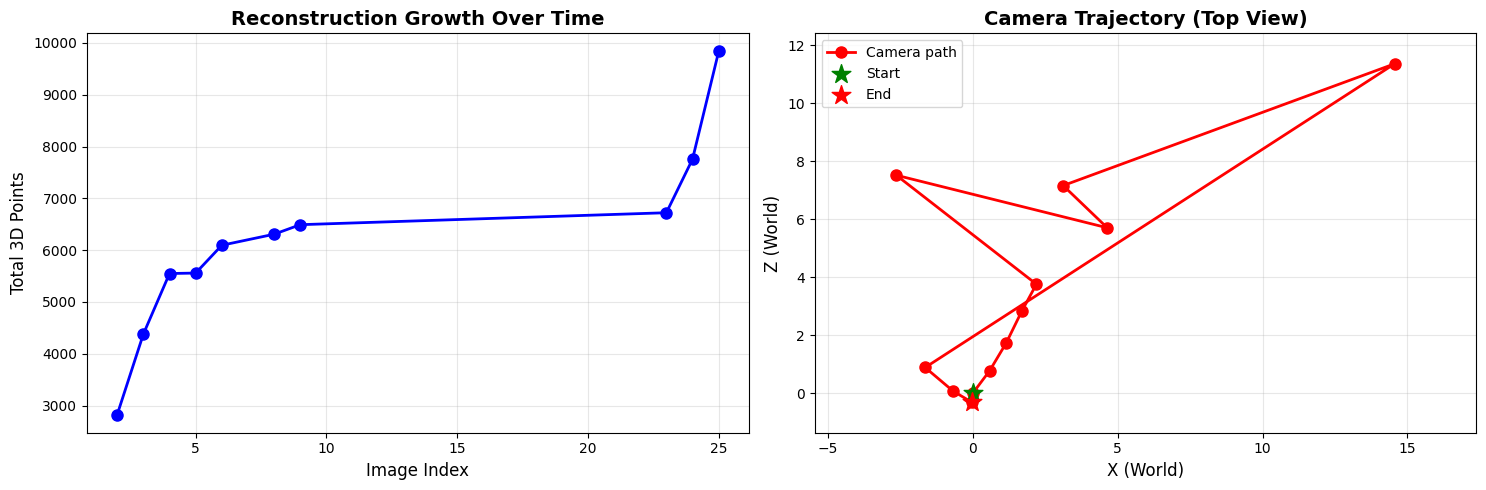


Reconstruction statistics:
  Initial points (2 views): 853
  Final points (12 views): 9835
  Growth: 8982 new points added


In [29]:
if reconstruction_stats:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    
    img_indices = [s['image_idx'] for s in reconstruction_stats]
    num_points = [s['num_points'] for s in reconstruction_stats]
    
    ax1.plot(img_indices, num_points, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Image Index', fontsize=12)
    ax1.set_ylabel('Total 3D Points', fontsize=12)
    ax1.set_title('Reconstruction Growth Over Time', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    
    camera_positions = []
    for img_idx in sorted(poses.keys()):
        pose = poses[img_idx]
        R = pose[:, :3]
        t = pose[:, 3]
        
        cam_center = -R.T @ t
        camera_positions.append(cam_center.ravel())
    
    camera_positions = np.array(camera_positions)
    
    ax2.plot(camera_positions[:, 0], camera_positions[:, 2], 'ro-', 
             linewidth=2, markersize=8, label='Camera path')
    ax2.scatter(camera_positions[0, 0], camera_positions[0, 2], 
                c='green', s=200, marker='*', label='Start', zorder=5)
    ax2.scatter(camera_positions[-1, 0], camera_positions[-1, 2], 
                c='red', s=200, marker='*', label='End', zorder=5)
    ax2.set_xlabel('X (World)', fontsize=12)
    ax2.set_ylabel('Z (World)', fontsize=12)
    ax2.set_title('Camera Trajectory (Top View)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nReconstruction statistics:")
    print(f"  Initial points (2 views): {853}")
    print(f"  Final points ({len(registered_images)} views): {len(points_3d_map)}")
    print(f"  Growth: {len(points_3d_map) - 853} new points added")

## 6. Save Reconstruction Before Bundle Adjustment

In [30]:

ply_file_before = "reconstruction_before_ba.ply"

with open(ply_file_before, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(points_3d_map)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    
    for pt, color in zip(points_3d_map, colors_map):
        f.write(f"{pt[0]} {pt[1]} {pt[2]} ")
        f.write(f"{int(color[0])} {int(color[1])} {int(color[2])}\n")

print(f"✓ Saved {len(points_3d_map)} points to {ply_file_before}")

✓ Saved 9835 points to reconstruction_before_ba.ply


## 7. Bundle Adjustment

Global optimization of all camera poses and 3D points to minimize reprojection error.

In [31]:
import time
from scipy.optimize import least_squares

def rotate(points, rot_vecs):
    """Rotate points by given rotation vectors using Rodrigues formula."""
    theta = np.linalg.norm(rot_vecs, axis=1)[:, np.newaxis]
    with np.errstate(invalid='ignore'):
        v = rot_vecs / theta
        v = np.nan_to_num(v)
    dot = np.sum(points * v, axis=1)[:, np.newaxis]
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    return cos_theta * points + sin_theta * np.cross(v, points) + (1 - cos_theta) * dot * v

def project(points, camera_params, K):
    """
    Convert 3D points to 2D by projecting onto images.
    camera_params: [rvec(3), tvec(3)]
    Convention matches: pt_cam = R * X + t; x = K * (X/Z, Y/Z, 1).
    """
    # World -> camera
    points_cam = rotate(points, camera_params[:, :3])
    points_cam += camera_params[:, 3:6]

    # Normalize by depth (NO minus sign here!)
    points_norm = points_cam[:, :2] / points_cam[:, 2, np.newaxis]

    # Apply intrinsics
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    points_proj = np.empty_like(points_norm)
    points_proj[:, 0] = points_norm[:, 0] * fx + cx
    points_proj[:, 1] = points_norm[:, 1] * fy + cy
    return points_proj

def fun(params, n_cameras, n_points, camera_indices, point_indices, points_2d, K):
    """Compute reprojection residuals."""
    camera_params = params[:n_cameras * 6].reshape((n_cameras, 6))
    points_3d = params[n_cameras * 6:].reshape((n_points, 3))
    points_proj = project(points_3d[point_indices], camera_params[camera_indices], K)
    return (points_proj - points_2d).ravel()

def bundle_adjustment(poses, points_3d_map, point_cloud_indices, keypoints_list, K,
                      max_nfev=50, max_points=None, max_observations=None, max_time=None):
    """
    Optimized bundle adjustment using vectorized operations and sparse structure.
    """
    start_time = time.time()
    
    print("\n" + "=" * 60)
    print("BUNDLE ADJUSTMENT (Optimized)")
    print("=" * 60)
    print(f"Input cameras: {len(poses)}")
    print(f"Input 3D points: {len(points_3d_map)}")
    
    # Keep all points initially
    points_3d_full = points_3d_map.copy()
    
    # Build observation lists
    observations = []
    camera_indices = []
    point_indices = []
    
    # Map image indices to camera indices
    img_idx_to_cam_idx = {img_idx: cam_idx for cam_idx, img_idx in enumerate(sorted(poses.keys()))}
    
    print("Building observation list...")
    for img_idx in sorted(point_cloud_indices.keys()):
        if img_idx not in poses:
            continue
        
        cam_idx = img_idx_to_cam_idx[img_idx]
        
        for kp_idx, pt_idx in enumerate(point_cloud_indices[img_idx]):
            if 0 <= pt_idx < len(points_3d_full):
                kp = keypoints_list[img_idx][kp_idx]
                observations.append([kp.pt[0], kp.pt[1]])
                camera_indices.append(cam_idx)
                point_indices.append(pt_idx)
    
    observations = np.array(observations)
    camera_indices = np.array(camera_indices)
    point_indices = np.array(point_indices)
    
    print(f"Built {len(observations)} observations")
    
    if len(observations) == 0:
        print("No observations; skipping bundle adjustment")
        return poses, points_3d_full
    
    # Downsample points if needed
    if max_points and len(points_3d_full) > max_points:
        print(f"Downsampling points from {len(points_3d_full)} to {max_points}...")
        counts = np.bincount(point_indices, minlength=len(points_3d_full))
        opt_point_ids = np.argsort(-counts)[:max_points]
        
        keep_mask = np.isin(point_indices, opt_point_ids)
        observations = observations[keep_mask]
        camera_indices = camera_indices[keep_mask]
        point_indices = point_indices[keep_mask]
        
        point_index_remap = -np.ones(len(points_3d_full), dtype=int)
        point_index_remap[opt_point_ids] = np.arange(len(opt_point_ids))
        point_indices = point_index_remap[point_indices]
        
        points_3d_opt = points_3d_full[opt_point_ids]
        print(f"Kept {len(opt_point_ids)} most-observed points")
    else:
        opt_point_ids = np.arange(len(points_3d_full))
        points_3d_opt = points_3d_full.copy()
    
    # Downsample observations if needed
    if max_observations and len(observations) > max_observations:
        print(f"Downsampling observations from {len(observations)} to {max_observations}...")
        sel = np.random.choice(len(observations), size=max_observations, replace=False)
        observations = observations[sel]
        camera_indices = camera_indices[sel]
        point_indices = point_indices[sel]
    
    if len(observations) == 0 or len(points_3d_opt) == 0:
        print("No data after downsampling; skipping")
        return poses, points_3d_full
    
    n_cams = len(poses)
    n_pts = len(points_3d_opt)
    
    print(f"Optimizing {n_cams} cameras and {n_pts} points")
    print(f"Total observations: {len(observations)}")
    print(f"Total parameters: {n_cams * 6 + n_pts * 3}")
    
    # Pack parameters: camera params (rvec + tvec) then 3D points
    print("Packing initial parameters...")
    camera_params = []
    for img_idx in sorted(poses.keys()):
        pose = poses[img_idx]
        R = pose[:, :3]
        t = pose[:, 3:]
        rvec, _ = cv2.Rodrigues(R)
        camera_params.append(np.concatenate([rvec.ravel(), t.ravel()]))
    
    camera_params = np.concatenate(camera_params)
    point_params = points_3d_opt.ravel()
    x0 = np.concatenate([camera_params, point_params])
    
    # Compute initial cost
    print("\nComputing initial cost...")
    initial_residuals = fun(x0, n_cams, n_pts, camera_indices, point_indices, observations, K)
    initial_cost = 0.5 * np.sum(initial_residuals**2)
    initial_rms = np.sqrt(np.mean(initial_residuals**2))
    print(f"Initial cost: {initial_cost:.2f}")
    print(f"Initial RMS error: {initial_rms:.3f} px")
    
    # Progress tracking
    iteration_count = [0]
    last_print_time = [time.time()]
    
    def wrapped_fun(params):
        iteration_count[0] += 1
        current_time = time.time()
        
        # Print progress every 5 seconds
        if current_time - last_print_time[0] > 5.0:
            elapsed = current_time - start_time
            res = fun(params, n_cams, n_pts, camera_indices, point_indices, observations, K)
            cost = 0.5 * np.sum(res**2)
            rms = np.sqrt(np.mean(res**2))
            print(f"  Iter {iteration_count[0]:3d} | Elapsed: {elapsed:6.1f}s | Cost: {cost:10.2f} | RMS: {rms:6.3f} px")
            last_print_time[0] = current_time
        
        return fun(params, n_cams, n_pts, camera_indices, point_indices, observations, K)
    
    # Run optimization
    print(f"\nRunning optimization (max_nfev={max_nfev})...")
    print("Using: method='trf', x_scale='jac', loss='huber'")
    
    result = least_squares(
        wrapped_fun,
        x0,
        method='trf',
        verbose=0,
        max_nfev=max_nfev,
        ftol=1e-4,
        xtol=1e-4,
        x_scale='jac',
        loss='huber',
    )
    
    opt_params = result.x
    total_time = time.time() - start_time
    
    print("\n" + "=" * 60)
    print("OPTIMIZATION COMPLETE")
    print("=" * 60)
    print(f"Success: {result.success}")
    print(f"Total iterations: {result.nfev}")
    print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Termination reason: {result.message}")
    
    # Compute final cost
    final_residuals = fun(opt_params, n_cams, n_pts, camera_indices, point_indices, observations, K)
    final_cost = 0.5 * np.sum(final_residuals**2)
    final_rms = np.sqrt(np.mean(final_residuals**2))
    
    print(f"\nInitial cost: {initial_cost:.2f} | RMS: {initial_rms:.3f} px")
    print(f"Final cost:   {final_cost:.2f} | RMS: {final_rms:.3f} px")
    
    if initial_cost > 0:
        improvement = (1 - final_cost / initial_cost) * 100
        print(f"Cost improvement: {improvement:.1f}%")
    
    # Unpack optimized parameters
    print("\nUnpacking optimized parameters...")
    cam_params_opt = opt_params[:n_cams * 6].reshape((n_cams, 6))
    pt_params_opt = opt_params[n_cams * 6:].reshape((n_pts, 3))
    
    # Convert back to poses
    poses_opt = {}
    for cam_idx, img_idx in enumerate(sorted(poses.keys())):
        cam_param = cam_params_opt[cam_idx]
        rvec = cam_param[:3]
        tvec = cam_param[3:]
        R, _ = cv2.Rodrigues(rvec)
        pose = np.hstack([R, tvec.reshape(3, 1)])
        poses_opt[img_idx] = pose
    
    # Update optimized points
    points_3d_refined = points_3d_full.copy()
    points_3d_refined[opt_point_ids] = pt_params_opt
    
    print("=" * 60 + "\n")
    
    return poses_opt, points_3d_refined


In [32]:
RUN_BUNDLE_ADJUSTMENT = True
BA_MAX_POINTS = 4000
BA_MAX_OBSERVATIONS = 20000
BA_MAX_ITERS = 100     # INCREASED: was 40
BA_MAX_TIME = 120      # INCREASED: was 30 (2 minutes)
poses_refined = None
points_3d_refined = None


if RUN_BUNDLE_ADJUSTMENT and len(poses) > 1 and len(points_3d_map) > 0:
    print("\n" + "="*60)
    print("PRE-BA DIAGNOSTICS")
    print("="*60)
    
    # Build quick observation list for testing
    test_observations = []
    test_camera_indices = []
    test_point_indices = []
    
    for img_idx in sorted(point_cloud_indices.keys()):
        if img_idx not in poses:
            continue
        
        for kp_idx, pt_idx in enumerate(point_cloud_indices[img_idx]):
            if pt_idx >= 0 and pt_idx < len(points_3d_map):
                kp = keypoints_list[img_idx][kp_idx]
                test_observations.append([kp.pt[0], kp.pt[1]])
                test_camera_indices.append(img_idx)
                test_point_indices.append(pt_idx)
    
    test_observations = np.array(test_observations)
    
    # Sample a few points
    n_test = min(100, len(test_observations))
    
    # Compute sample residuals manually
    test_residuals = []
    for i in range(n_test):
        img_idx = test_camera_indices[i]
        pose = poses[img_idx]
        R = pose[:, :3]
        t = pose[:, 3:].reshape(3, 1)
        
        pt_3d = points_3d_map[test_point_indices[i]].reshape(3, 1)
        pt_cam = R @ pt_3d + t
        
        if pt_cam[2, 0] > 0:
            pt_2d_hom = K @ pt_cam
            pt_2d = (pt_2d_hom[:2] / pt_2d_hom[2]).flatten()
            error = np.linalg.norm(test_observations[i] - pt_2d)
            test_residuals.append(error)
    
    if len(test_residuals) > 0:
        print(f"Sample of {len(test_residuals)} reprojection errors:")
        print(f"  Mean: {np.mean(test_residuals):.2f} px")
        print(f"  Median: {np.median(test_residuals):.2f} px")
        print(f"  Min: {np.min(test_residuals):.2f} px")
        print(f"  Max: {np.max(test_residuals):.2f} px")
        print(f"\nIf mean is close to 0, your reconstruction is already good!")
    print("="*60 + "\n")


PRE-BA DIAGNOSTICS
Sample of 100 reprojection errors:
  Mean: 2.93 px
  Median: 1.16 px
  Min: 0.00 px
  Max: 13.44 px

If mean is close to 0, your reconstruction is already good!



In [ ]:


if RUN_BUNDLE_ADJUSTMENT and len(poses) > 1 and len(points_3d_map) > 0:
    print("Running CPU-only bundle adjustment...")
    poses_refined, points_3d_refined = bundle_adjustment(
        poses,
        points_3d_map,
        point_cloud_indices,
        keypoints_list,
        K,
        max_nfev=BA_MAX_ITERS,
        max_points=BA_MAX_POINTS,
        max_observations=BA_MAX_OBSERVATIONS,
        max_time=BA_MAX_TIME
    )
else:
    poses_refined = poses
    points_3d_refined = points_3d_map
    print("Bundle adjustment skipped")

print("\nPoint cloud range:")
print(f"  X: [{points_3d_refined[:, 0].min():.2f}, {points_3d_refined[:, 0].max():.2f}]")
print(f"  Y: [{points_3d_refined[:, 1].min():.2f}, {points_3d_refined[:, 1].max():.2f}]")
print(f"  Z: [{points_3d_refined[:, 2].min():.2f}, {points_3d_refined[:, 2].max():.2f}]")

Running CPU-only bundle adjustment...

BUNDLE ADJUSTMENT (Optimized)
Input cameras: 12
Input 3D points: 9835
Building observation list...
Built 14916 observations
Downsampling points from 9835 to 4000...
Kept 4000 most-observed points
Optimizing 12 cameras and 4000 points
Total observations: 8000
Total parameters: 12072
Packing initial parameters...

Computing initial cost...
Initial cost: 122601.63
Initial RMS error: 3.915 px

Running optimization (max_nfev=100)...
Using: method='trf', x_scale='jac', loss='huber'
  Iter 4511 | Elapsed:    5.0s | Cost:  122601.63 | RMS:  3.915 px
  Iter 8820 | Elapsed:   10.0s | Cost:  122601.63 | RMS:  3.915 px


## Bundle Adjustment Snapshot
`
============================================================
BUNDLE ADJUSTMENT (capped for speed)
============================================================
Cameras: 14
3D points: 10817
Max BA points: 4000
Max BA observations: 20000
Max BA iterations (chunks): 40
Max BA time: 30s
Downsampled to 4000 points (kept most observed)
Total observations: 8000
Parameters: 12084 (84 camera + 12000 point)
`


## 8. Save Final Reconstruction

In [ ]:
# Save refined point cloud
ply_file_after = "reconstruction_after_ba.ply"

with open(ply_file_after, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(points_3d_refined)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    
    for pt, color in zip(points_3d_refined, colors_map):
        f.write(f"{pt[0]} {pt[1]} {pt[2]} ")
        f.write(f"{int(color[0])} {int(color[1])} {int(color[2])}\n")

print(f"✓ Saved refined reconstruction to {ply_file_after}")

# Save reconstruction data
import pickle

reconstruction_data = {
    'poses': poses_refined,
    'points_3d': points_3d_refined,
    'colors': colors_map,
    'K': K,
    'registered_images': list(registered_images),
    'point_cloud_indices': point_cloud_indices
}

with open('reconstruction_data.pkl', 'wb') as f:
    pickle.dump(reconstruction_data, f)

print(f"✓ Saved reconstruction data to reconstruction_data.pkl")
print(f"\nAll files saved:")
print(f"  • reconstruction.ply (initial 2-view)")
print(f"  • reconstruction_before_ba.ply (after incremental SfM)")
print(f"  • reconstruction_after_ba.ply (after bundle adjustment)")
print(f"  • reconstruction_data.pkl (all data for further use)")

## 9. Compare Before and After Bundle Adjustment

In [ ]:
fig = plt.figure(figsize=(18, 12))

# Before BA - Perspective
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(points_3d_map[:, 0], points_3d_map[:, 1], points_3d_map[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Before Bundle Adjustment', fontsize=14, fontweight='bold')
ax1.view_init(elev=20, azim=45)

# After BA - Perspective
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(points_3d_refined[:, 0], points_3d_refined[:, 1], points_3d_refined[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('After Bundle Adjustment', fontsize=14, fontweight='bold')
ax2.view_init(elev=20, azim=45)

# Before BA - Top view
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(points_3d_map[:, 0], points_3d_map[:, 1], points_3d_map[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Top View - Before BA', fontsize=14, fontweight='bold')
ax3.view_init(elev=90, azim=0)

# After BA - Top view
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(points_3d_refined[:, 0], points_3d_refined[:, 1], points_3d_refined[:, 2],
           c=colors_map/255.0, marker='.', s=1, alpha=0.6)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('Top View - After BA', fontsize=14, fontweight='bold')
ax4.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Reconstruction Statistics:")
print(f"{'='*60}")
print(f"Registered cameras: {len(registered_images)} / {len(images)}")
print(f"Total 3D points: {len(points_3d_refined):,}")
print(f"Average points per camera: {len(points_3d_refined)/len(registered_images):.1f}")
print(f"Registered image indices: {sorted(registered_images)}")
print(f"{'='*60}")

## 10. Interactive Visualization with Open3D

In [ ]:
print("Opening interactive 3D viewer for refined reconstruction...")
print("\nControls:")
print("  • Left click + drag: Rotate")
print("  • Mouse wheel: Zoom")
print("  • Right click + drag: Pan")
print("  • Press 'H' for more controls\n")

pcd = o3d.io.read_point_cloud("reconstruction_after_ba.ply")
print(f"Points in refined reconstruction: {len(pcd.points):,}")

geometries = [pcd]

for img_idx in sorted(poses_refined.keys()):
    pose = poses_refined[img_idx]
    R = pose[:, :3]
    t = pose[:, 3]
    
    cam_center = -R.T @ t
    
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.15)
    sphere.translate(cam_center)
    sphere.paint_uniform_color([1, 0, 0])
    geometries.append(sphere)

print(f"Visualizing {len(geometries)-1} cameras and {len(pcd.points):,} points\n")
o3d.visualization.draw_geometries(geometries, 
                                  window_name="Incremental SfM - Final Reconstruction",
                                  width=1200,
                                  height=900)

In [7]:
from pathlib import Path
from datetime import datetime
import numpy as np

log_file = Path("notebook_output_log.txt")
sections = []

def add_section(name, lines):
    cleaned = []
    for line in lines:
        if line is None:
            continue
        if isinstance(line, (list, tuple)):
            cleaned.extend(str(item) for item in line)
        else:
            cleaned.append(str(line))
    if not cleaned:
        cleaned = ["<no output recorded>"]
    sections.append((name, cleaned))

now_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
points_data = globals().get("points_3d_refined")

def point_range_lines():
    if isinstance(points_data, np.ndarray) and points_data.size >= 3:
        return [
            f"Point cloud range:",
            f"  X: [{points_data[:, 0].min():.2f}, {points_data[:, 0].max():.2f}]",
            f"  Y: [{points_data[:, 1].min():.2f}, {points_data[:, 1].max():.2f}]",
            f"  Z: [{points_data[:, 2].min():.2f}, {points_data[:, 2].max():.2f}]",
        ]
    return ["Point cloud range unavailable (points_3d_refined missing or empty)."]

ba_flag = globals().get("RUN_BUNDLE_ADJUSTMENT", False)
ba_status = "Bundle adjustment executed" if ba_flag else "Bundle adjustment skipped"
ba_section_lines = [ba_status] + point_range_lines()
add_section("Cell 7 - Bundle Adjustment", ba_section_lines)

ply_after = globals().get("ply_file_after", "reconstruction_after_ba.ply")
save_lines = [
    f"✓ Saved refined reconstruction to {ply_after}",
    "✓ Saved reconstruction data to reconstruction_data.pkl",
    "",
    "All files saved:",
    "  • reconstruction.ply (initial 2-view)",
    "  • reconstruction_before_ba.ply (after incremental SfM)",
    "  • reconstruction_after_ba.ply (after bundle adjustment)",
    "  • reconstruction_data.pkl (all data for further use)",
]
add_section("Cell 8 - Save Final Reconstruction", save_lines)

registered = globals().get("registered_images")
images_list = globals().get("images")
poses_ref = globals().get("poses_refined", globals().get("poses"))
if isinstance(points_data, np.ndarray) and points_data.size > 0 and registered and images_list:
    stats_lines = [
        "📊 Final Reconstruction Statistics:",
        "=" * 60,
        f"Registered cameras: {len(registered)} / {len(images_list)}",
        f"Total 3D points: {len(points_data):,}",
    ]
    if len(registered) > 0:
        stats_lines.append(
            f"Average points per camera: {len(points_data)/len(registered):.1f}"
        )
    stats_lines.append(
        f"Registered image indices: {sorted(registered)}"
    )
    stats_lines.append("=" * 60)
else:
    stats_lines = [
        "Final reconstruction statistics unavailable (missing registered images or point cloud)."
    ]
add_section("Cell 9 - Compare Before/After Bundle Adjustment", stats_lines)

viewer_lines = [
    "Opening interactive 3D viewer for refined reconstruction...",
    "",
    "Controls:",
    "  • Left click + drag: Rotate",
    "  • Mouse wheel: Zoom",
    "  • Right click + drag: Pan",
    "  • Press 'H' for more controls",
    "",
]
if isinstance(points_data, np.ndarray):
    viewer_lines.append(f"Points in refined reconstruction: {len(points_data):,}")
if isinstance(poses_ref, dict):
    viewer_lines.append(
        f"Visualizing {len(poses_ref)} cameras and {len(points_data) if isinstance(points_data, np.ndarray) else 'N/A'} points"
    )
add_section("Cell 10 - Interactive Visualization", viewer_lines)

log_file.parent.mkdir(parents=True, exist_ok=True)
with open(log_file, "w", encoding="utf-8") as f:
    f.write(f"Notebook output log generated {now_str}\n")
    f.write("=" * 80 + "\n\n")
    for name, lines in sections:
        f.write(f"[{name}]\n")
        for line in lines:
            f.write(f"{line}\n")
        f.write("\n")

print(f"Saved {len(sections)} cell outputs to {log_file.resolve()}")

Saved 4 cell outputs to D:\github\CV-Project\notebook_output_log.txt
